## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import (
    cross_validate, cross_val_predict,
)
from sklearn.metrics import classification_report, confusion_matrix, make_scorer
from xgboost import XGBClassifier

## Load data

In [2]:
BINARY_TARGET = False
INCLUDE_GEX = True

In [3]:

clinical_gex = pd.read_csv(
    '../dataset/created/clinical_gex.csv',
    low_memory=False
)
clinical_gex.columns = clinical_gex.columns.str.strip()

if BINARY_TARGET == True:
    clinical_gex = clinical_gex[clinical_gex['pfs_label'].isin([0,2])]
    clinical_gex['pfs_label'] = clinical_gex['pfs_label'].replace(2, 1)
    
groups = clinical_gex['source']

y = clinical_gex['pfs_label']
x = clinical_gex.drop(['patientID', 'pfs_label', 'PFS_month', 'sample_id', 'source', 'brain_metastasis', 'source_right', 'pfs_label_right'], axis=1)

print(x.head())
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")

      sex  age AJCC_stage M_stage       LDH immunotherapy_treatment  \
0    male   26         IV     M1B  elevated                      no   
1  female   58         IV     M1A    normal                      no   
2    male   45         IV     M1A    normal                      no   
3    male   48       IIIC     NaN    normal                      no   
4    male   33         IV     M1C    normal                      no   

  pre_MAPKi_treatment  cobimetinib  dabrafenib  trametinib  ...    LRFN2  \
0                  no            0           0           0  ...  4.00089   
1                  no            0           0           0  ...  4.00089   
2                  no            0           0           0  ...  4.00089   
3                  no            1           0           0  ...  4.00089   
4                  no            1           0           0  ...  4.00089   

     MAGEA3     ABHD6     ARL10     DNHD1      PPIH      TFF3       PBK  \
0  6.287460  5.764514  4.015359  4.416253

In [4]:
# Clinical columns that need preprocessing
clinical_ordinal_col = ['M_stage']
clinical_categorical_cols = [
    'sex', 'AJCC_stage', 'LDH',
    'immunotherapy_treatment', 'pre_MAPKi_treatment'
]
clinical_numeric_col = ['age']

drug_braf_cols = [
    'cobimetinib', 'trametinib', 'dabrafenib', 'vemurafenib',
    'C195W', 'K601I', 'R558Q', 'MND', 'V600E', 'V600K', 'V600R'
]

# Gene expression columns (everything else)
all_non_gex = (
    clinical_ordinal_col + clinical_categorical_cols +
    clinical_numeric_col + drug_braf_cols
)
gex_cols = [c for c in x.columns if c not in all_non_gex]

print(f"\nClinical features: {len(clinical_ordinal_col) + len(clinical_categorical_cols) + len(clinical_numeric_col)}")
print(f"Drug/BRAF dummies: {len(drug_braf_cols)}")
print(f"Gene expression features: {len(gex_cols)}")


Clinical features: 7
Drug/BRAF dummies: 11
Gene expression features: 122


## Preprocessing pipeline

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

if INCLUDE_GEX == True:
    remainder='passthrough'
else:
    remainder='drop'

clinical_preprocessor = ColumnTransformer(
    transformers=[
        ('m_stage', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(
                categories=[['M1A', 'M1B', 'M1C']],
                handle_unknown='use_encoded_value',
                unknown_value=np.nan
            )),
        ]), clinical_ordinal_col),

        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
        ]), clinical_categorical_cols),

        ('age', SimpleImputer(strategy='median'), clinical_numeric_col),
        ('drug_braf', 'passthrough', drug_braf_cols)
    ],
    remainder=remainder # gene expressions
)

x_processed = clinical_preprocessor.fit_transform(x)
x_processed = pd.DataFrame(x_processed, columns=clinical_preprocessor.get_feature_names_out())
x_processed

,m_stage__M_stage,categorical__sex_female,categorical__sex_male,categorical__AJCC_stage_IIIC,categorical__AJCC_stage_IV,categorical__LDH_elevated,categorical__LDH_normal,categorical__immunotherapy_treatment_no,categorical__pre_MAPKi_treatment_no,age__age,...,remainder__LRFN2,remainder__MAGEA3,remainder__ABHD6,remainder__ARL10,remainder__DNHD1,remainder__PPIH,remainder__TFF3,remainder__PBK,remainder__FGF13,remainder__EXOSC3
0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,26.0,...,4.000890,6.287460,5.764514,4.015359,4.416253,6.739738,5.003677,5.890783,5.189148,6.328000
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,58.0,...,4.000890,6.865694,6.033802,4.041276,4.613856,6.862496,5.049185,6.070983,5.128801,6.472128
2,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,45.0,...,4.000890,5.629798,5.750640,4.011071,4.651746,6.769417,5.008392,5.894473,5.628744,6.725773
3,2.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,48.0,...,4.000890,4.951684,5.756891,4.040749,4.414295,6.522390,5.060871,5.740850,5.146984,6.301930
4,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,33.0,...,4.000890,6.267340,5.995879,4.037211,4.800719,6.959851,5.064195,5.650680,5.206566,6.415380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,61.0,...,3.955080,5.588604,5.533848,4.147227,4.689609,6.613560,4.545481,6.263270,4.477394,6.552303
133,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,65.0,...,3.959119,5.743312,5.934002,4.042794,4.596366,7.157491,4.677891,5.256349,4.782940,6.214688
134,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,51.0,...,3.956035,6.232833,6.397838,4.018834,4.672454,6.785056,4.520856,5.695232,5.693097,6.958281
135,2.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,41.0,...,3.957076,5.327856,5.884653,4.051610,4.621599,7.386782,4.652919,5.917283,4.422212,6.718769


In [6]:
x = x_processed.copy()

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, RFECV

rfecv = RFECV(
    estimator=RandomForestClassifier(random_state=42), 
    step=1,
    cv=5
)

rfe = RFE(
    estimator=RandomForestClassifier(random_state=42), 
    step=1, 
    n_features_to_select=15
)

x_rfe = rfe.fit_transform(x, y)
x_rfe = pd.DataFrame(x_rfe, columns=rfe.get_feature_names_out())
x_rfe

,remainder__MAGEA1,remainder__BAIAP2L1,remainder__HES6,remainder__COMMD9,remainder__SCRG1,remainder__SLC31A1,remainder__TUBA8,remainder__FBXW8,remainder__PMEPA1,remainder__FAM89B,remainder__ADAM9,remainder__C1QTNF9B,remainder__TUBB3,remainder__ARHGAP28,remainder__ABHD6
0,5.189127,5.596766,6.705595,6.412474,5.401353,6.201200,4.139555,5.258780,5.883385,6.771879,6.170284,4.598046,7.447856,4.627395,5.764514
1,5.436335,5.724922,6.763863,6.603374,5.359955,6.970775,6.052653,5.385078,5.886229,6.800401,6.088457,4.614575,7.987326,4.581680,6.033802
2,4.943710,5.540081,6.687989,6.385018,5.691432,6.273811,3.979848,5.125964,5.911821,6.742250,6.556477,4.596732,6.596889,4.674432,5.750640
3,4.544665,5.671164,6.704425,6.477311,5.384306,6.456244,3.854256,5.096196,5.975301,6.662519,6.507061,4.592083,7.068522,5.192750,5.756891
4,4.866010,5.681413,6.730892,6.604500,6.249443,6.410716,3.951927,5.383356,5.901840,6.908469,6.240415,4.600331,7.427956,4.782657,5.995879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,5.966658,5.200485,5.952482,6.313222,5.892004,6.174425,4.034702,5.114374,6.104066,6.977488,6.137293,4.504534,7.484206,4.910955,5.533848
133,4.994948,5.373717,6.717448,6.973932,6.827238,6.147887,5.606173,5.185268,6.021461,7.746210,5.284150,4.660710,8.204823,4.890538,5.934002
134,4.770290,5.181882,6.015571,7.146914,5.404074,6.513855,4.062016,5.012645,7.910137,6.333731,5.228944,4.522280,7.272301,4.834946,6.397838
135,4.760104,5.077981,6.411734,6.660055,4.392794,6.683745,4.049267,5.108319,5.053869,7.491095,6.084041,4.456323,7.203186,4.845455,5.884653


## Hyperparams tuning

In [27]:
CLASSIFIER = 'lr'
CV = 'logo'
x = x_rfe.copy()

In [28]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

if CLASSIFIER == 'xgboost':
    if BINARY_TARGET:
        clf = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
        )
    else:
        clf = XGBClassifier(
            objective='multi:softprob',
            num_class=3,
            eval_metric='mlogloss',
            random_state=42,
        )
elif CLASSIFIER == 'lr':
    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            solver='saga',
            class_weight='balanced',
            max_iter=5000,
            random_state=42,
        ))
    ])
    

def objective(trial):
    if CLASSIFIER == 'xgboost':
        params = {
            'n_estimators': 100,
            'max_depth': trial.suggest_int('max_depth', 1, 3),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 50.0, log=True),  # Force higher L2 regularization to keep the model conservative.
            'min_child_weight': trial.suggest_int('min_child_weight', 3, 10),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        }
    
    elif CLASSIFIER == 'lr':
        params = {
            'clf__C': trial.suggest_float('clf__C', 0.0001, 0.01, log=True), # Very small C = Strong penalty
        }

    clf.set_params(**params)

    if CV == 'logo':
        scores = cross_val_score(clf, x, y, groups=groups, cv=logo, scoring='f1_macro', n_jobs=-1)
    elif CV == 'skf':
        scores = cross_val_score(clf, x, y, cv=skf, scoring='f1_macro', n_jobs=-1)

    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

print("Best params:", study.best_params)
print("Best CV F1 macro:", study.best_value)

[I 2026-04-15 15:39:57,014] A new study created in memory with name: no-name-34292955-28b7-4acf-bb79-f825537dcfdc
[I 2026-04-15 15:39:58,817] Trial 0 finished with value: 0.6251267251267251 and parameters: {'clf__C': 0.000380431293353109}. Best is trial 0 with value: 0.6251267251267251.
[I 2026-04-15 15:39:59,839] Trial 1 finished with value: 0.6289511927128026 and parameters: {'clf__C': 0.000615055651501552}. Best is trial 1 with value: 0.6289511927128026.
[I 2026-04-15 15:40:00,864] Trial 2 finished with value: 0.6778395458058379 and parameters: {'clf__C': 0.0031605966711424874}. Best is trial 2 with value: 0.6778395458058379.
[I 2026-04-15 15:40:01,875] Trial 3 finished with value: 0.6733843193843194 and parameters: {'clf__C': 0.008861506166846384}. Best is trial 2 with value: 0.6778395458058379.
[I 2026-04-15 15:40:01,902] Trial 4 finished with value: 0.6144837471795997 and parameters: {'clf__C': 0.00017030234105250955}. Best is trial 2 with value: 0.6778395458058379.
[I 2026-04-15

Best params: {'clf__C': 0.00288207962052953}
Best CV F1 macro: 0.6795575905575906


## Run models

Test ROC-AUC (OVO) : nan ± nan
Test Macro F1      : 0.680 ± 0.198
Train ROC-AUC (OVO): 0.885 ± 0.039
Train Macro F1     : 0.755 ± 0.053


              precision    recall  f1-score   support

  Short resp       0.75      0.87      0.81        71
Intermediate       0.88      0.66      0.75        32
   Long resp       0.60      0.53      0.56        34

    accuracy                           0.74       137
   macro avg       0.74      0.69      0.71       137
weighted avg       0.74      0.74      0.73       137



/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 166, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 417, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
   

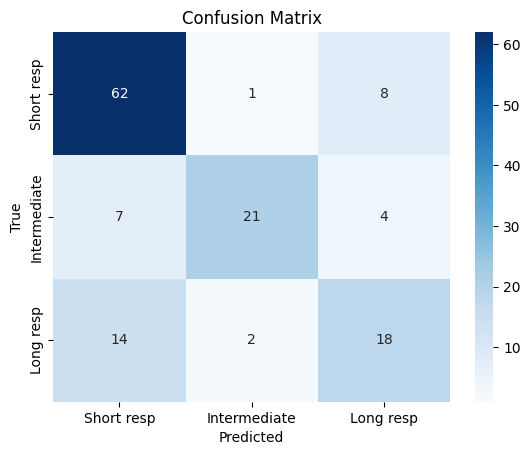

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# best_params = {'n_estimators': 184, 'max_depth': 5, 'learning_rate': 0.05152470968190831, 'subsample': 0.5179110300627818, 'colsample_bytree': 0.8798562191354427, 'reg_alpha': 0.011850627705610592, 'reg_lambda': 0.07233876044528072, 'min_child_weight': 1, 'gamma': 0.10039466141134781}

clf.set_params(**study.best_params)

if CV == 'logo':
    results = cross_validate(
        clf, x, y,
        cv=logo,
        groups=groups,
        scoring=['roc_auc_ovo', 'f1_macro'],
        return_train_score=True,
        n_jobs=-1
    )
    y_pred = cross_val_predict(
        clf, x, y, 
        cv=logo,
        groups=groups,
        n_jobs=-1
    )
elif CV == 'skf':
    results = cross_validate(
        clf, x, y,
        cv=skf,
        scoring=['roc_auc_ovo', 'f1_macro'],
        return_train_score=True,
        n_jobs=-1
    )
    y_pred = cross_val_predict(
        clf, x, y, cv=skf,
        n_jobs=-1
    )

if BINARY_TARGET == True:
    target_names = ['Short resp', 'Long resp']
else:
    target_names = ['Short resp', 'Intermediate', 'Long resp']

print(f"Test ROC-AUC (OVO) : {results['test_roc_auc_ovo'].mean():.3f} ± {results['test_roc_auc_ovo'].std():.3f}")
print(f"Test Macro F1      : {results['test_f1_macro'].mean():.3f} ± {results['test_f1_macro'].std():.3f}")
print(f"Train ROC-AUC (OVO): {results['train_roc_auc_ovo'].mean():.3f} ± {results['train_roc_auc_ovo'].std():.3f}")
print(f"Train Macro F1     : {results['train_f1_macro'].mean():.3f} ± {results['train_f1_macro'].std():.3f}")

print("\n")
print(classification_report(
    y, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## Explanability

In [11]:
import shap

model = xgboost_clf.fit(x, y)
explainer = shap.TreeExplainer(model)
shap_values = explainer(x)

predicted_class = int(model.predict(x)[0])
print(f'Predicted class: {predicted_class}')

x_display = x.copy()

# Column is already renamed to M_stage
m_stage_map = {0: "M1A", 1: "M1B", 2: "M1C"}
x_display["M_stage"] = x_display["M_stage"].map(m_stage_map)

sv = shap.Explanation(
    values=shap_values.values[0, :, predicted_class],
    base_values=float(shap_values.base_values[0, predicted_class]),
    data=x_display.iloc[0].values,
    feature_names=x_display.columns.tolist()
)

shap.plots.waterfall(sv)
plt.show()

NameError: name 'xgboost_clf' is not defined